In [29]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from quantauto.data import load_market_data

MSFT_DAILY = ROOT / "market_data" / "ForMulti" / "MSFT" / "1d.csv"

loaded = load_market_data(MSFT_DAILY, verbose=True)
print(f"Asset : MSFT (S&P 500) — daily bars")
print(f"Rows  : {len(loaded.data)}")
print(f"Range : {loaded.data.index.min().date()} → {loaded.data.index.max().date()}")
loaded.data[['open', 'high', 'low', 'close', 'volume']].tail(5)

loaded market data: 1256 rows, index [2021-04-26 04:00:00+00:00 .. 2026-04-24 04:00:00+00:00]
  timestamp: index <= timestamp
  open: open
  high: high
  low: low
  close: close
  volume: volume
Asset : MSFT (S&P 500) — daily bars
Rows  : 1256
Range : 2021-04-26 → 2026-04-24


,open,high,low,close,volume
2026-04-20 04:00:00+00:00,421.149994,423.329987,416.299988,418.070007,27582200
2026-04-21 04:00:00+00:00,420.239990,427.179993,417.200012,424.160004,32048500
2026-04-22 04:00:00+00:00,426.190002,433.700012,423.670013,432.920013,29378200
2026-04-23 04:00:00+00:00,419.890015,423.660004,411.410004,415.750000,38308000
2026-04-24 04:00:00+00:00,416.970001,424.950012,415.799988,424.619995,27413900


[run_auto] starting pipeline
[run_auto:single] validating input rows=1256
[run_auto:single] features engineered rows=1256 cols=21
[run_auto:single] feature names: ret_1, log_ret_1, sma_20, ema_12, std_20, zscore_20, roc_10, rsi_14, macd_line, macd_signal, macd_hist, bb_mid, bb_upper, bb_lower, bb_width, bb_pctb, atr_14, obv, vol_ratio, hl_range, close_pos
[run_auto:single] label built task=classification horizon=1 label_name=target_direction
[run_auto:single] dataset built rows=1221 cols=21
[LightGBM] [Info] Number of positive: 239, number of negative: 250
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3437
[LightGBM] [Info] Number of data points in the train set: 489, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488753 -> initscore=-0.044997
[Light

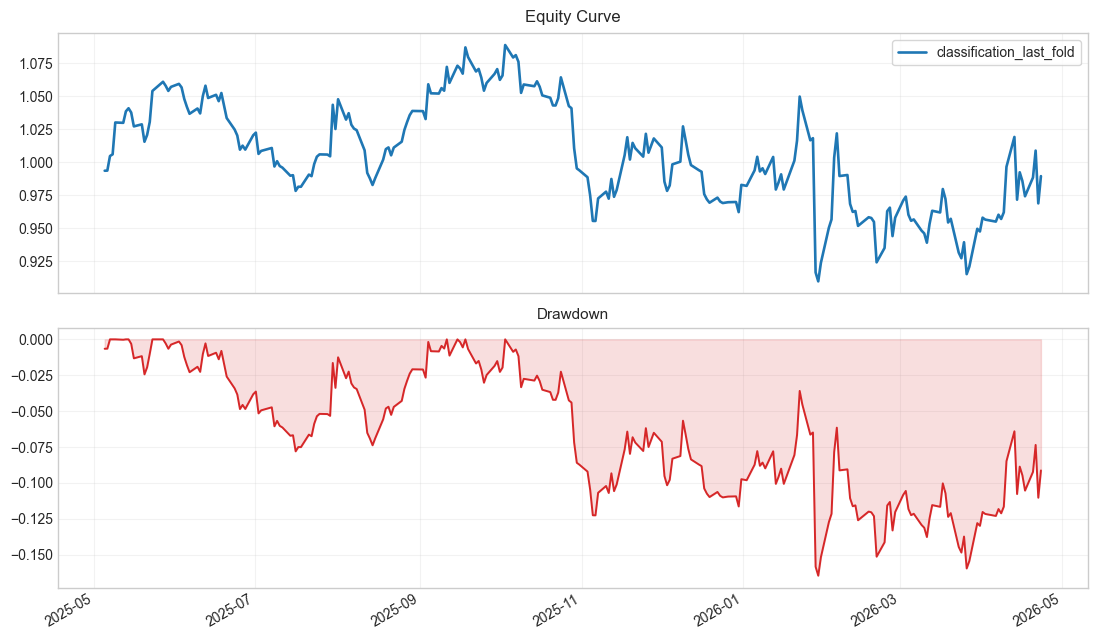

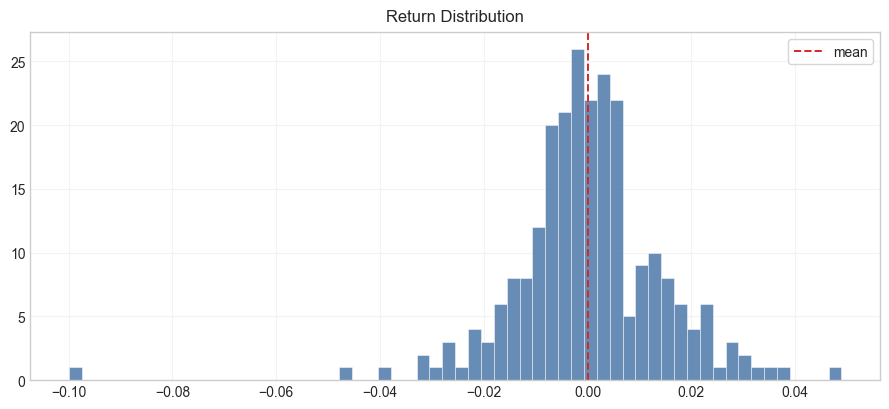

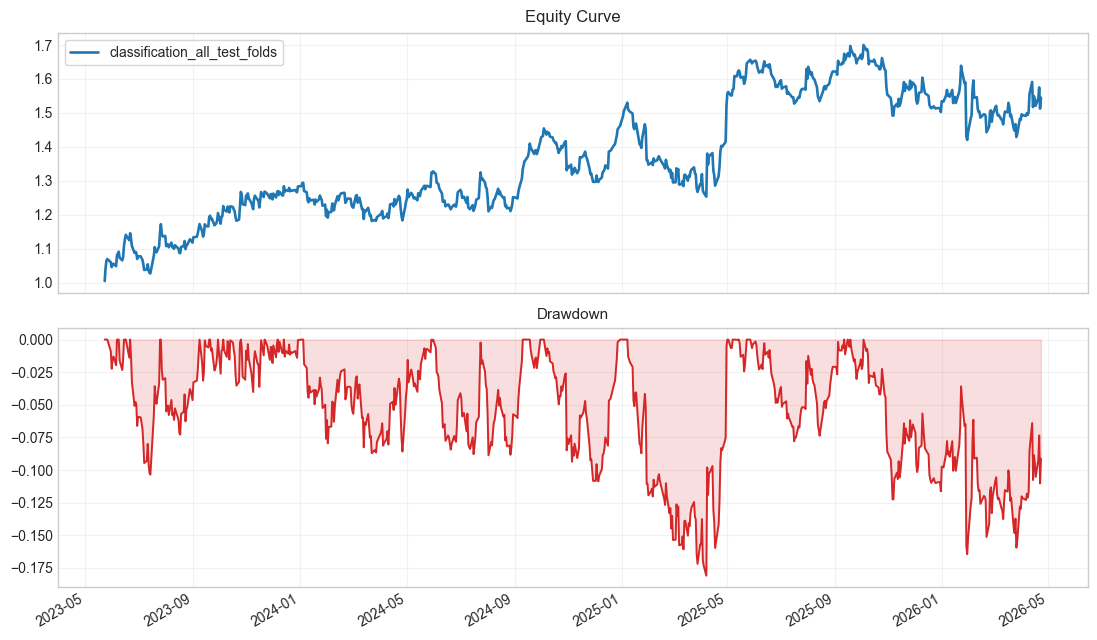

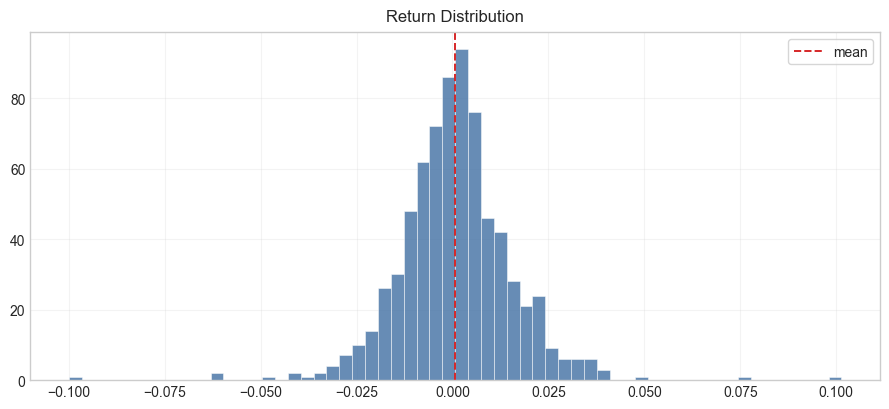

In [30]:
from quantauto.workflows import run_auto

results = run_auto(
    data=MSFT_DAILY,
    target_type='classification',
    target_horizon=1,
    threshold=0.0,
    feature_preset='base',
    execution_shift=1,
    test_split=0.2,
    walk_forward_folds=3,
    model_ids=('gbm_clf', 'xgb_clf', 'logreg'),
    training_time_budget='5m',
    enable_layer2=False,
    backtest_scope='both',
    fee_bps=2.0,
    slippage_bps=1.0,
    enable_backtest_plots=True,
    backtest_default_plots=('equity_curve', 'returns_distribution'),
    verbose=2,
)